In [7]:
#importing models and libraries
from src.detector import DamageDetector
from src.assessment import DamageAssessment

import matplotlib.pyplot as plt
import pandas as pd

In [27]:
MODEL_PATH = "./models/best.pt"

detector = DamageDetector(MODEL_PATH)
assessment_engine = DamageAssessment()

print("Model Loaded Successfully", MODEL_PATH)

Model Loaded Successfully ./models/best.pt


In [28]:
#select any test image
IMAGE_PATH = "./data/test/images/000040.jpg"
print("Image Path:")
print(IMAGE_PATH)

Image Path:
./data/test/images/000040.jpg


In [29]:
# run detection
annotated_image, detections = detector.detect(IMAGE_PATH)
print(f"Total Raw Detections: {len(detections)}")

Total Raw Detections: 1


In [30]:
#run assessment
assessment = assessment_engine.assess(detections)

In [31]:
# vehicle summary
summary = assessment["summary"]
print("VEHICLE DAMAGE SUMMARY")
for key, value in summary.items():
    print(f"{key.replace('_',' ').title():25}: {value}")

VEHICLE DAMAGE SUMMARY
Total Damages            : 1
Overall Severity         : Medium
Vehicle Health           : Fair
Risk Score               : 55
Inspection Status        : Needs Inspection


In [32]:
# damage details
# Create DataFrame
damage_df = pd.DataFrame(assessment["damages"])

# Select only user-friendly columns
damage_df = damage_df[
    [
        "damage_type",
        "confidence",
        "confidence_level",
        "severity",
        "location",
        "damage_size",
        "estimated_cost",
        "repair_priority",
        "recommendation"
    ]
]

# Rename columns for display
damage_df.columns = [
    "Damage Type",
    "Confidence (%)",
    "Confidence Level",
    "Severity",
    "Location",
    "Damage Size",
    "Estimated Cost",
    "Repair Priority",
    "Recommendation"
]

damage_df

,Damage Type,Confidence (%),Confidence Level,Severity,Location,Damage Size,Estimated Cost,Repair Priority,Recommendation
0,Scratch,53.0,Low,Medium,Center Body,Medium,"₹2,000 - ₹6,000",Medium,Buffing and repainting recommended.


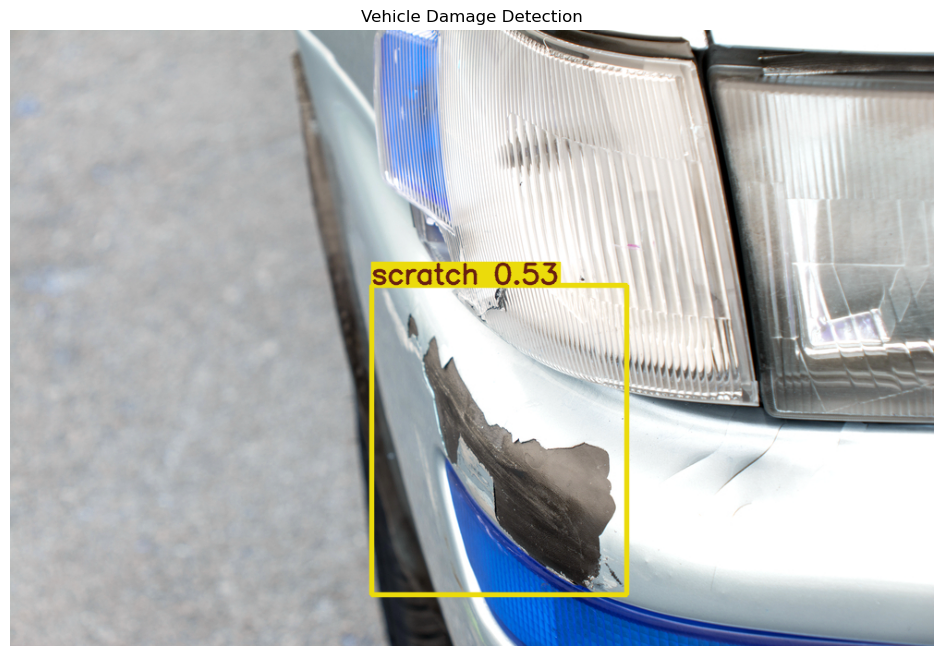

In [33]:
# show annotated image
plt.figure(figsize=(12,8))
plt.imshow(annotated_image)
plt.axis("off")
plt.title("Vehicle Damage Detection")
plt.show()

In [ ]:
# save prediction image
OUTPUT_PATH = "./reports/figures/prediction.jpg"
detector.save_prediction(
    annotated_image,
    OUTPUT_PATH
)
print("Prediction image saved successfully.")
print(OUTPUT_PATH)

Prediction image saved successfully.
reports/figures/prediction.jpg


In [35]:
# save assessment object
assessment

{'summary': {'total_damages': 1,
  'overall_severity': 'Medium',
  'vehicle_health': 'Fair',
  'risk_score': 55,
  'inspection_status': 'Needs Inspection'},
 'damages': [{'damage_type': 'Scratch',
   'confidence': 53.0,
   'confidence_level': 'Low',
   'location': 'Center Body',
   'severity': 'Medium',
   'coverage': 13.86,
   'damage_size': 'Medium',
   'recommendation': 'Buffing and repainting recommended.',
   'estimated_cost': '₹2,000 - ₹6,000',
   'repair_priority': 'Medium'}]}